# Analisis exploratorio: operadores de vecindad en MetaCARP

**Corpus**: `resultados_consolidados.csv` (92,529 corridas de 5 metaheuristicas
sobre 23 instancias pequenas: gdb1-7, gdb10, gdb12-17, gdb19-21, kshs1-6).

**Pregunta motora**: de los 9 operadores de vecindad disponibles
(3 intra-ruta + 6 inter-ruta), cuales producen mejoras de forma consistente
a traves de instancias y metaheuristicas, y cuales son candidatos a poda?

**Las metricas clave por operador** (cada una repetida para los 9 ops):
- `propuesto_{op}`: veces que la metaheuristica intento aplicar el operador
- `aceptado_{op}`: veces que el vecino generado fue aceptado como solucion actual
- `mejoraron_{op}`: veces que el operador produjo una mejora sobre la solucion actual
- `trayectoria_mejor_{op}`: veces que el operador participo en la trayectoria del mejor global

Este notebook NO toma decisiones de poda todavia, solo genera la evidencia.

## 1. Setup y carga de datos

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual: paleta limpia y tamano consistente
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Mostrar mas filas/cols en pandas
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

In [2]:
RUTA_CSV = Path('resultados_consolidados.csv')
df = pd.read_csv(RUTA_CSV, low_memory=False)
print(f'Filas:    {len(df):,}')
print(f'Columnas: {len(df.columns)}')
df.head(3)

Filas:    92,529
Columnas: 55


,metaheuristica,instancia,bks_referencia,bks_origen,gap_bks_porcentaje,repeticion,semilla,tiempo_segundos,mejor_costo,costo_solucion_inicial,propuesto_relocate_intra,propuesto_swap_intra,propuesto_2opt_intra,propuesto_relocate_inter,propuesto_swap_inter,propuesto_2opt_star,propuesto_cross_exchange,propuesto_or_opt_2,propuesto_or_opt_3,aceptado_relocate_intra,aceptado_swap_intra,aceptado_2opt_intra,aceptado_relocate_inter,aceptado_swap_inter,aceptado_2opt_star,aceptado_cross_exchange,aceptado_or_opt_2,aceptado_or_opt_3,mejoraron_relocate_intra,mejoraron_swap_intra,mejoraron_2opt_intra,mejoraron_relocate_inter,mejoraron_swap_inter,mejoraron_2opt_star,mejoraron_cross_exchange,mejoraron_or_opt_2,mejoraron_or_opt_3,trayectoria_mejor_relocate_intra,trayectoria_mejor_swap_intra,trayectoria_mejor_2opt_intra,trayectoria_mejor_relocate_inter,trayectoria_mejor_swap_inter,trayectoria_mejor_2opt_star,trayectoria_mejor_cross_exchange,trayectoria_mejor_or_opt_2,trayectoria_mejor_or_opt_3,iteraciones_totales,mejoras,mejor_solucion_factible_final,mejor_solucion_tr_legible,reporte_detalle_deadheading,costo_total_desde_reporte,parametros_especificos,archivo_origen,carpeta_origen
0,recocido_simulado,gdb1,316.0000,BKS,27.5316,2,NaN,2.1610,403.0000,462.0000,644,853,825,757,893,979,985,946,862,198,276,245,117,241,208,196,34,5,3,1,2,2,1,1,0,0,0,198,276,245,117,240,206,196,34,5,7744,10,True,R1: D -> TR3 -> TR16 -> TR18 -> TR19 -> TR9 ->...,"VEHÍCULO #1:\n [SERVICIO] TR3 (1,7) | Costo: ...",403.0000,"{""L_cadena_markov"": 484, ""aceptadas"": 1520, ""a...",resumen_mejores_corridas.csv,sa_small_simple
1,recocido_simulado,gdb2,339.0000,BKS,31.2684,1,NaN,4.5776,445.0000,550.0000,858,1047,1119,1690,2117,1932,2026,1975,2108,241,258,270,194,488,423,380,99,39,3,2,1,3,6,4,3,0,0,234,255,266,194,481,381,372,99,37,14872,22,True,R1: D -> TR1 -> TR9 -> TR25 -> TR8 -> TR12 -> ...,"VEHÍCULO #1:\n [SERVICIO] TR1 (1,2) | Costo: ...",445.0000,"{""L_cadena_markov"": 676, ""aceptadas"": 2392, ""a...",resumen_mejores_corridas.csv,sa_small_simple
2,recocido_simulado,gdb3,275.0000,BKS,49.0909,2,NaN,3.1097,410.0000,435.0000,1027,1272,1381,1160,1441,1528,1381,1456,1454,374,431,497,164,432,354,313,63,16,2,1,1,2,3,3,0,0,0,369,430,495,162,429,345,311,62,16,12100,12,True,R1: D -> TR2 -> TR3 -> TR17 -> TR19 -> TR11 ->...,"VEHÍCULO #1:\n [SERVICIO] TR2 (1,4) | Costo: ...",410.0000,"{""L_cadena_markov"": 484, ""aceptadas"": 2644, ""a...",resumen_mejores_corridas.csv,sa_small_simple


In [3]:
# Los 9 operadores agrupados por categoria (intra vs inter ruta)
OPS_INTRA = ['relocate_intra', 'swap_intra', '2opt_intra']
OPS_INTER = ['relocate_inter', 'swap_inter', '2opt_star',
             'cross_exchange', 'or_opt_2', 'or_opt_3']
OPS = OPS_INTRA + OPS_INTER

# Helpers para acceder a las 4 perspectivas
def cols(prefijo): return [f'{prefijo}_{op}' for op in OPS]
COLS_PROPUESTO  = cols('propuesto')
COLS_ACEPTADO   = cols('aceptado')
COLS_MEJORARON  = cols('mejoraron')
COLS_TRAY_MEJOR = cols('trayectoria_mejor')

## 2. Resumen general del corpus

Verificamos volumen por metaheuristica, instancias presentes y BKS de referencia.

In [4]:
# Conteo de corridas por metaheuristica
resumen_mh = (df.groupby('metaheuristica')
                .agg(n_corridas=('mejor_costo', 'size'),
                     instancias=('instancia', 'nunique'),
                     tiempo_total_s=('tiempo_segundos', 'sum'),
                     tiempo_mediano_s=('tiempo_segundos', 'median'))
                .sort_values('n_corridas', ascending=False))
resumen_mh

,n_corridas,instancias,tiempo_total_s,tiempo_mediano_s
metaheuristica,,,,
tabu_reactiva,34500,23,"108,140.9775",2.1715
busqueda_abejas_simple,27600,23,"33,071.3235",0.9359
cuckoo_search,27600,23,"14,041.3062",0.4289
recocido_simulado,2553,23,"22,033.2838",3.6140
busqueda_tabu_simple,276,23,100.1509,0.3097


In [5]:
# Cobertura instancia x MH (deberia ser homogenea: ~mismo numero de combos por celda)
cobertura = df.groupby(['metaheuristica', 'instancia']).size().unstack(fill_value=0)
print('Forma:', cobertura.shape)
cobertura

Forma: (5, 23)


instancia,gdb1,gdb10,gdb12,gdb13,gdb14,gdb15,gdb16,gdb17,gdb19,gdb2,gdb20,gdb21,gdb3,gdb4,gdb5,gdb6,gdb7,kshs1,kshs2,kshs3,kshs4,kshs5,kshs6
metaheuristica,,,,,,,,,,,,,,,,,,,,,,,
busqueda_abejas_simple,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
busqueda_tabu_simple,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
cuckoo_search,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
recocido_simulado,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111,111
tabu_reactiva,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500


In [6]:
# BKS de referencia por instancia (deberia ser unico)
bks = (df.groupby('instancia')
         .agg(bks=('bks_referencia', 'first'),
              n_distintos=('bks_referencia', 'nunique'))
         .sort_index())
assert bks['n_distintos'].max() == 1, 'BKS inconsistente entre corridas de la misma instancia'
bks.drop(columns='n_distintos')

,bks
instancia,
gdb1,316.0000
gdb10,275.0000
gdb12,458.0000
gdb13,536.0000
gdb14,100.0000
gdb15,58.0000
gdb16,127.0000
gdb17,91.0000
gdb19,55.0000


## 3. Calidad de soluciones por metaheuristica

Antes de mirar operadores, contextualizamos cuanto tan bien funciona cada MH.
El operador mas usado por una MH mediocre puede no ser util en una MH ganadora.

In [7]:
# Estadisticas de gap respecto al BKS (menor = mejor)
calidad = (df.groupby('metaheuristica')['gap_bks_porcentaje']
             .agg(['mean', 'median', 'std', 'min', 'max'])
             .round(3))
calidad

,mean,median,std,min,max
metaheuristica,,,,,
busqueda_abejas_simple,43.4150,42.7930,12.9660,14.1340,85.1530
busqueda_tabu_simple,28.6700,27.5860,12.6430,-1.5690,54.5450
cuckoo_search,45.8580,46.0180,14.0990,14.5450,121.3970
recocido_simulado,32.6950,31.8580,10.6520,14.1340,58.6930
tabu_reactiva,28.5080,27.5860,12.4930,-1.5690,53.0910


In [8]:
# Tasa de factibilidad del mejor global encontrado (debe ser 1.0 o muy cercana)
(df.groupby('metaheuristica')['mejor_solucion_factible_final']
   .mean()
   .rename('tasa_factibilidad').round(4))

metaheuristica
busqueda_abejas_simple   1.0000
busqueda_tabu_simple     0.0036
cuckoo_search            0.8872
recocido_simulado        1.0000
tabu_reactiva            0.0144
Name: tasa_factibilidad, dtype: float64

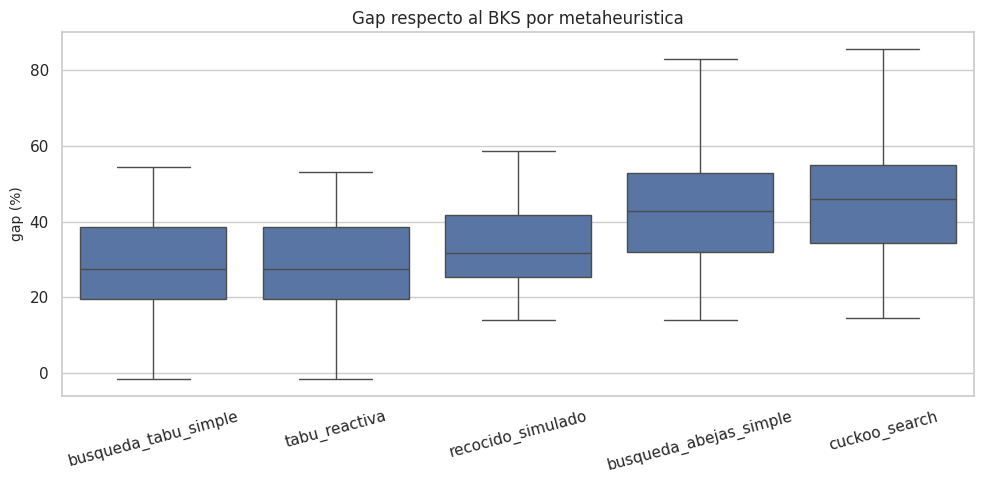

In [9]:
# Distribucion del gap por MH para ver dispersion
fig, ax = plt.subplots(figsize=(10, 5))
orden = (df.groupby('metaheuristica')['gap_bks_porcentaje']
           .median().sort_values().index)
sns.boxplot(data=df, x='metaheuristica', y='gap_bks_porcentaje',
            order=orden, ax=ax, showfliers=False)
ax.set_title('Gap respecto al BKS por metaheuristica')
ax.set_xlabel('')
ax.set_ylabel('gap (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Analisis del uso de operadores

Las cuatro perspectivas (`propuesto`, `aceptado`, `mejoraron`, `trayectoria_mejor`)
miden distintas dimensiones del valor de un operador:

- **Propuesto**: cuanto lo usa la politica (sesgo inter/intra + uniforme dentro del grupo)
- **Tasa de aceptacion** = aceptado / propuesto: que tan facil es que el vecino sea adoptado
- **Tasa de mejora**    = mejoraron / propuesto: cuantas veces produjo una solucion mejor que la actual
- **Contribucion a mejor** = trayectoria_mejor / propuesto: cuanto contribuyo a refinar el mejor global

Notese que un operador con alta aceptacion pero baja mejora solo esta moviendo lateral.

### 4.1 Sumas globales por operador

In [10]:
# Totales agregados a traves de TODAS las corridas (todas MH, todas instancias, todas reps)
totales = pd.DataFrame({
    'propuesto':         df[COLS_PROPUESTO].sum().values,
    'aceptado':          df[COLS_ACEPTADO].sum().values,
    'mejoraron':         df[COLS_MEJORARON].sum().values,
    'trayectoria_mejor': df[COLS_TRAY_MEJOR].sum().values,
}, index=OPS)
totales['tasa_aceptacion'] = totales['aceptado']  / totales['propuesto']
totales['tasa_mejora']     = totales['mejoraron'] / totales['propuesto']
totales['contrib_mejor']   = totales['trayectoria_mejor'] / totales['propuesto']
totales['grupo'] = ['intra']*3 + ['inter']*6
totales.round(4)

,propuesto,aceptado,mejoraron,trayectoria_mejor,tasa_aceptacion,tasa_mejora,contrib_mejor,grupo
relocate_intra,47548192,6135252,66972,3879107,0.1290,0.0014,0.0816,intra
swap_intra,60371569,7018959,80397,4635686,0.1163,0.0013,0.0768,intra
2opt_intra,60378303,6908789,87517,4646849,0.1144,0.0014,0.0770,intra
relocate_inter,70251785,3124997,64152,1634715,0.0445,0.0009,0.0233,inter
swap_inter,88158561,4663852,94133,2771217,0.0529,0.0011,0.0314,inter
2opt_star,88154558,5487534,99273,2554803,0.0622,0.0011,0.0290,inter
cross_exchange,87547149,4206166,73873,2305524,0.0480,0.0008,0.0263,inter
or_opt_2,88461460,2815534,53385,1209954,0.0318,0.0006,0.0137,inter
or_opt_3,88469461,2483107,47209,945348,0.0281,0.0005,0.0107,inter


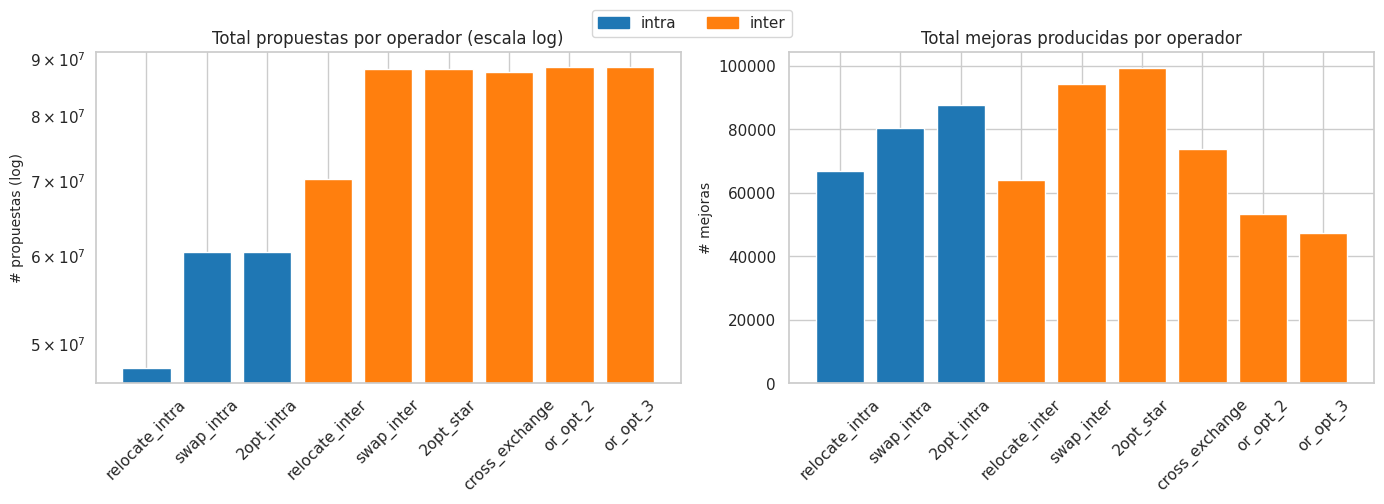

In [11]:
# Visualizacion: propuestas vs mejoras absolutas por operador
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#1f77b4' if g == 'intra' else '#ff7f0e' for g in totales['grupo']]

axes[0].bar(totales.index, totales['propuesto'], color=colores)
axes[0].set_title('Total propuestas por operador (escala log)')
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('# propuestas (log)')

axes[1].bar(totales.index, totales['mejoraron'], color=colores)
axes[1].set_title('Total mejoras producidas por operador')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('# mejoras')

from matplotlib.patches import Patch
handles = [Patch(color='#1f77b4', label='intra'), Patch(color='#ff7f0e', label='inter')]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

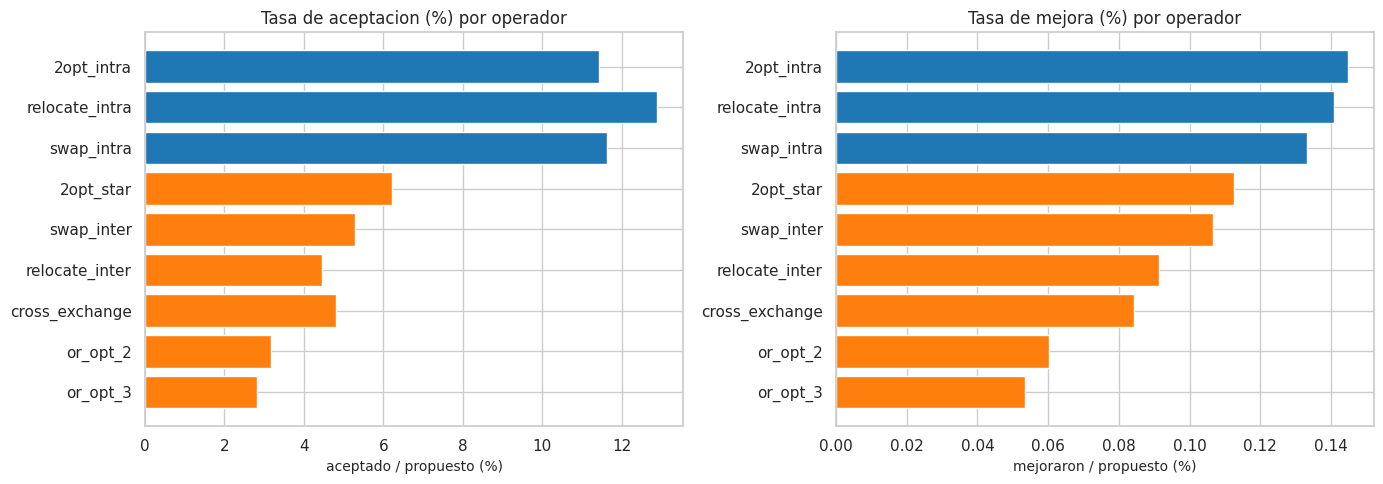

In [12]:
# Tasa de aceptacion y de mejora (en %) por operador, ordenadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tasas_ord = totales.sort_values('tasa_mejora', ascending=True)

axes[0].barh(tasas_ord.index, tasas_ord['tasa_aceptacion'] * 100,
             color=['#1f77b4' if g == 'intra' else '#ff7f0e' for g in tasas_ord['grupo']])
axes[0].set_title('Tasa de aceptacion (%) por operador')
axes[0].set_xlabel('aceptado / propuesto (%)')

axes[1].barh(tasas_ord.index, tasas_ord['tasa_mejora'] * 100,
             color=['#1f77b4' if g == 'intra' else '#ff7f0e' for g in tasas_ord['grupo']])
axes[1].set_title('Tasa de mejora (%) por operador')
axes[1].set_xlabel('mejoraron / propuesto (%)')

plt.tight_layout()
plt.show()

### 4.2 Tasa de mejora por metaheuristica x operador

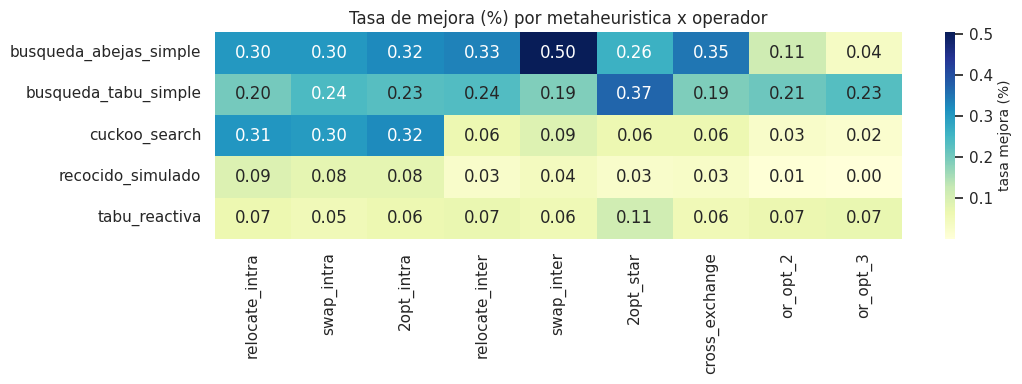

In [13]:
# Esta es la vista clave: la fila de cada MH muestra cuanta mejora obtuvo de cada operador.
# Un operador con celdas oscuras en varias MH es valioso transversalmente.

def agg_por_mh(df_in, cols_num, cols_den):
    '''Suma numerador y denominador por MH y devuelve el ratio. Evita NaN cuando den=0.'''
    num = df_in.groupby('metaheuristica')[cols_num].sum()
    den = df_in.groupby('metaheuristica')[cols_den].sum()
    num.columns = OPS
    den.columns = OPS
    return (num / den.replace(0, np.nan)).fillna(0)

tasa_mejora_mh = agg_por_mh(df, COLS_MEJORARON, COLS_PROPUESTO)
tasa_acept_mh  = agg_por_mh(df, COLS_ACEPTADO,  COLS_PROPUESTO)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(tasa_mejora_mh * 100, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'tasa mejora (%)'}, ax=ax)
ax.set_title('Tasa de mejora (%) por metaheuristica x operador')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

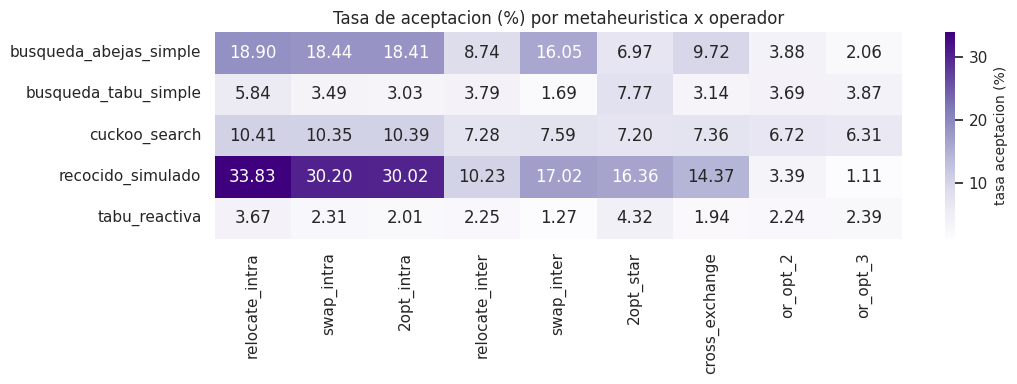

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(tasa_acept_mh * 100, annot=True, fmt='.2f', cmap='Purples',
            cbar_kws={'label': 'tasa aceptacion (%)'}, ax=ax)
ax.set_title('Tasa de aceptacion (%) por metaheuristica x operador')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.3 Contribucion a la trayectoria del mejor global

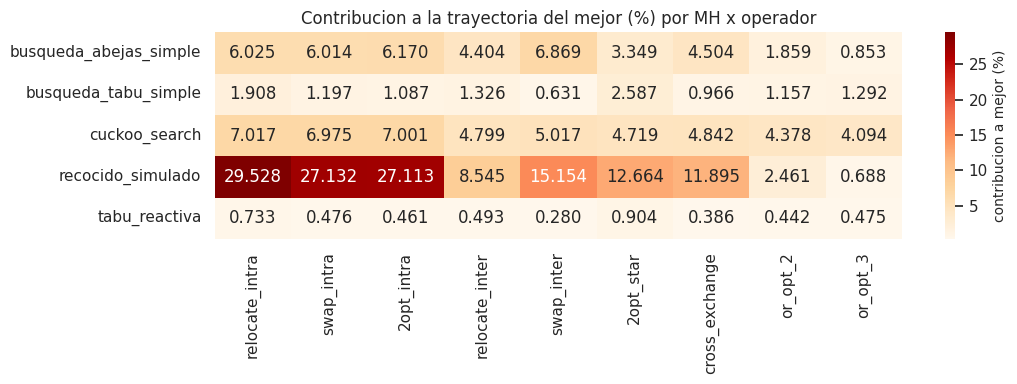

In [15]:
# trayectoria_mejor: cuantas veces el operador estuvo en el camino al mejor global.
# Es la metrica mas exigente: no basta con producir vecinos mejores que el actual,
# tiene que aportar al optimo global encontrado.

contrib_mh = agg_por_mh(df, COLS_TRAY_MEJOR, COLS_PROPUESTO)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(contrib_mh * 100, annot=True, fmt='.3f', cmap='OrRd',
            cbar_kws={'label': 'contribucion a mejor (%)'}, ax=ax)
ax.set_title('Contribucion a la trayectoria del mejor (%) por MH x operador')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.4 Variabilidad por instancia

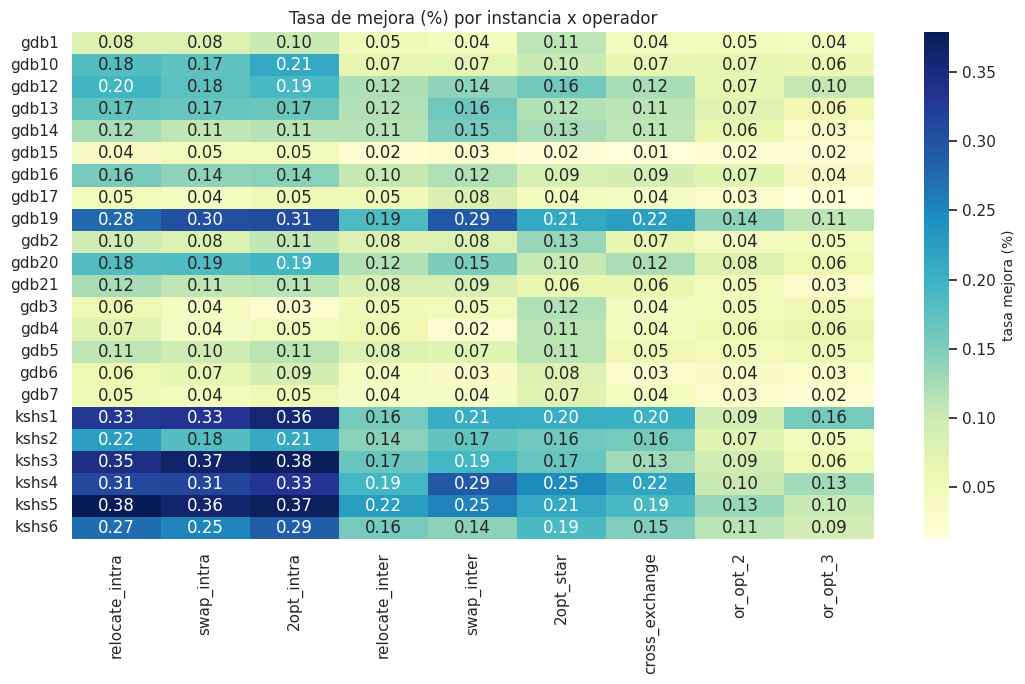

In [16]:
# Tasa de mejora promedio (sobre todas las corridas) para cada par operador-instancia.
# Si un operador es valioso solo en 2-3 instancias y nulo en el resto, es candidato a
# operador especializado y no general.

num_inst = df.groupby('instancia')[COLS_MEJORARON].sum()
den_inst = df.groupby('instancia')[COLS_PROPUESTO].sum()
num_inst.columns = OPS
den_inst.columns = OPS
tasa_mejora_inst = (num_inst / den_inst.replace(0, np.nan)).fillna(0)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(tasa_mejora_inst * 100, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'tasa mejora (%)'}, ax=ax)
ax.set_title('Tasa de mejora (%) por instancia x operador')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Operadores intra vs inter

Al sumar los tres operadores intra y los seis inter, comparamos el peso relativo de cada grupo.

In [17]:
intra_inter = pd.DataFrame({
    'intra': df[[f'mejoraron_{op}' for op in OPS_INTRA]].sum(axis=1),
    'inter': df[[f'mejoraron_{op}' for op in OPS_INTER]].sum(axis=1),
})
intra_inter['metaheuristica'] = df['metaheuristica']

# Promedio de mejoras absolutas por corrida, separado por grupo
g = intra_inter.groupby('metaheuristica')[['intra', 'inter']].sum()
g['fraccion_inter'] = g['inter'] / (g['intra'] + g['inter'])
g.round(3)

,intra,inter,fraccion_inter
metaheuristica,,,
busqueda_abejas_simple,79882,137514,0.6330
busqueda_tabu_simple,478,1956,0.8040
cuckoo_search,75112,41073,0.3540
recocido_simulado,28163,11549,0.2910
tabu_reactiva,51251,239933,0.8240


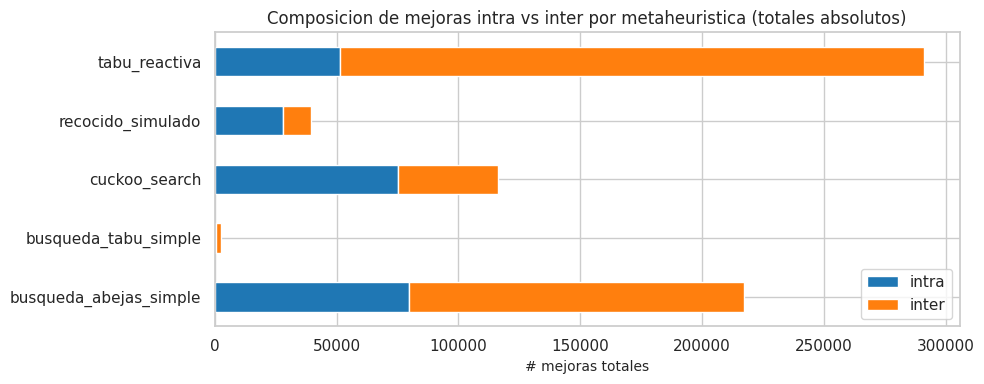

In [18]:
# Visualizacion stacked: composicion intra/inter en mejoras totales por MH
fig, ax = plt.subplots(figsize=(10, 4))
g[['intra', 'inter']].plot(kind='barh', stacked=True, ax=ax,
                            color=['#1f77b4', '#ff7f0e'])
ax.set_title('Composicion de mejoras intra vs inter por metaheuristica (totales absolutos)')
ax.set_xlabel('# mejoras totales')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Candidatos a poda: criterio multidimensional

Un operador es candidato a poda si cumple **simultaneamente**:

1. **Baja tasa de mejora** (mejoras / propuestas) en mas de 3 metaheuristicas
2. **Baja contribucion** a la trayectoria del mejor en mas de 3 MH
3. **Cobertura limitada de instancias** (solo aporta en pocas)

Los umbrales son orientativos; el objetivo aqui es generar la evidencia, no decidir.

In [19]:
# Construimos una tabla resumen por operador con las metricas clave consolidadas

resumen_op = pd.DataFrame(index=OPS)
resumen_op['grupo'] = ['intra']*3 + ['inter']*6
resumen_op['propuestas_totales']         = totales['propuesto']
resumen_op['mejoras_totales']            = totales['mejoraron']
resumen_op['tasa_mejora_global_%']       = totales['tasa_mejora'] * 100
resumen_op['contrib_mejor_global_%']     = totales['contrib_mejor'] * 100
resumen_op['mh_con_tasa_mejora_>1%']     = (tasa_mejora_mh > 0.01).sum()
resumen_op['mh_con_contrib_>0.5%']       = (contrib_mh > 0.005).sum()
resumen_op['instancias_con_mejora_>0']   = (tasa_mejora_inst > 0).sum()
resumen_op.sort_values('tasa_mejora_global_%', ascending=False).round(4)

,grupo,propuestas_totales,mejoras_totales,tasa_mejora_global_%,contrib_mejor_global_%,mh_con_tasa_mejora_>1%,mh_con_contrib_>0.5%,instancias_con_mejora_>0
2opt_intra,intra,60378303,87517,0.1449,7.6962,0,4,23
relocate_intra,intra,47548192,66972,0.1409,8.1583,0,5,23
swap_intra,intra,60371569,80397,0.1332,7.6786,0,4,23
2opt_star,inter,88154558,99273,0.1126,2.8981,0,5,23
swap_inter,inter,88158561,94133,0.1068,3.1434,0,4,23
relocate_inter,inter,70251785,64152,0.0913,2.3269,0,4,23
cross_exchange,inter,87547149,73873,0.0844,2.6335,0,4,23
or_opt_2,inter,88461460,53385,0.0603,1.3678,0,4,23
or_opt_3,inter,88469461,47209,0.0534,1.0686,0,4,23


In [20]:
# Ranking final de operadores: combinamos las metricas en un score 0-1 simple,
# normalizando cada columna a [0,1] y promediando. Sirve solo para ordenar.

metricas_score = ['tasa_mejora_global_%', 'contrib_mejor_global_%',
                   'mh_con_tasa_mejora_>1%', 'mh_con_contrib_>0.5%',
                   'instancias_con_mejora_>0']
norm = resumen_op[metricas_score].copy()
for c in metricas_score:
    rango = norm[c].max() - norm[c].min()
    norm[c] = (norm[c] - norm[c].min()) / rango if rango > 0 else 0.0
resumen_op['score_promedio'] = norm.mean(axis=1).round(3)

ranking = resumen_op.sort_values('score_promedio', ascending=False)
ranking[['grupo', 'tasa_mejora_global_%', 'contrib_mejor_global_%',
         'mh_con_tasa_mejora_>1%', 'instancias_con_mejora_>0', 'score_promedio']]

,grupo,tasa_mejora_global_%,contrib_mejor_global_%,mh_con_tasa_mejora_>1%,instancias_con_mejora_>0,score_promedio
relocate_intra,intra,0.1409,8.1583,0,23,0.5910
2opt_intra,intra,0.1449,7.6962,0,23,0.3870
2opt_star,inter,0.1126,2.8981,0,23,0.3810
swap_intra,intra,0.1332,7.6786,0,23,0.3610
swap_inter,inter,0.1068,3.1434,0,23,0.1750
relocate_inter,inter,0.0913,2.3269,0,23,0.1180
cross_exchange,inter,0.0844,2.6335,0,23,0.1120
or_opt_2,inter,0.0603,1.3678,0,23,0.0240
or_opt_3,inter,0.0534,1.0686,0,23,0.0000


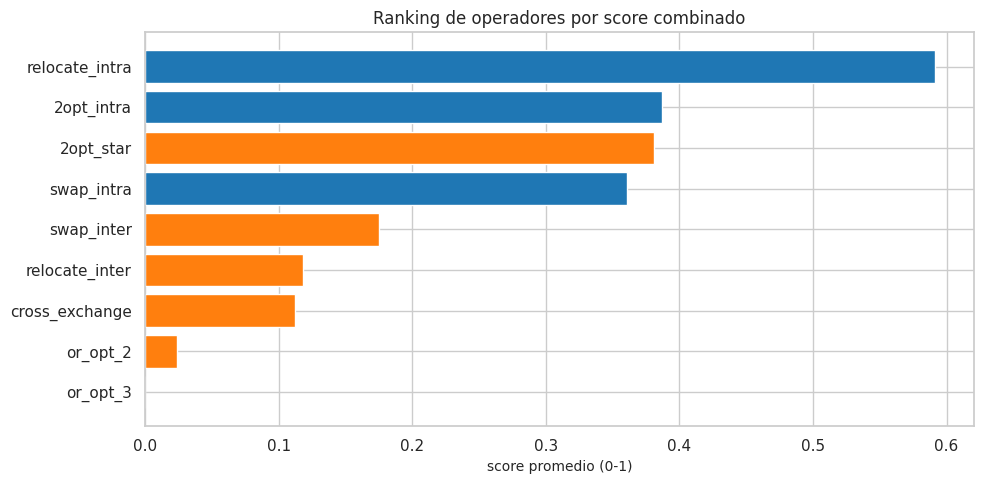

In [21]:
# Visualizacion del ranking
fig, ax = plt.subplots(figsize=(10, 5))
colores_rank = ['#1f77b4' if g == 'intra' else '#ff7f0e'
                for g in ranking['grupo']]
ax.barh(ranking.index, ranking['score_promedio'], color=colores_rank)
ax.set_xlabel('score promedio (0-1)')
ax.set_title('Ranking de operadores por score combinado')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Conclusiones

### 7.1 Ranking de operadores: lo que dicen los datos

Sobre el corpus de 92,529 corridas (5 MH x 23 instancias x N reps), ordenando
por el score combinado de la seccion 6 (tasa de mejora global, contribucion al
mejor global, presencia en MH e instancias):

| # | Operador           | Grupo | Tasa mejora | Contrib. mejor | Score | Veredicto                |
|---|--------------------|-------|-------------|----------------|-------|--------------------------|
| 1 | `relocate_intra`   | intra | 0.141%      | 8.16%          | 0.591 | Pilar (conservar)        |
| 2 | `2opt_intra`       | intra | 0.145%      | 7.70%          | 0.387 | Pilar (conservar)        |
| 3 | `2opt_star`        | inter | 0.113%      | 2.90%          | 0.381 | Util (conservar)         |
| 4 | `swap_intra`       | intra | 0.133%      | 7.68%          | 0.361 | Pilar (conservar)        |
| 5 | `swap_inter`       | inter | 0.107%      | 3.14%          | 0.175 | Util (conservar)         |
| 6 | `relocate_inter`   | inter | 0.091%      | 2.33%          | 0.118 | Marginal (revisar)       |
| 7 | `cross_exchange`   | inter | 0.084%      | 2.63%          | 0.112 | Marginal (revisar)       |
| 8 | `or_opt_2`         | inter | 0.060%      | 1.37%          | 0.024 | **Candidato a poda**     |
| 9 | `or_opt_3`         | inter | 0.053%      | 1.07%          | 0.000 | **Candidato a poda**     |

### 7.2 Hallazgos transversales

**Los operadores intra dominan en eficiencia relativa.** Los tres ocupan
posiciones top-4 por contribucion al mejor global (>7.5%), mientras los seis
inter quedan entre 1% y 3%. La intensificacion local sobre cada ruta es la
que cierra la mayor parte del gap, aunque las MH que tambien explotan el
movimiento entre rutas alcanzan mejor calidad final (siguiente punto).

**Las MH que mas usan inter son las mas competitivas.** Tabu reactiva
(82% de mejoras inter) y TS simple (80%) son las dos MH con menor gap al
BKS (~28.5%). Cuckoo (35% inter) y ABC (63% inter) terminan con gap >43%.
SA, con solo 29% inter, tiene gap intermedio (32.7%). El **balance**
inter/intra impacta mas en la calidad que cualquier operador individual.

**`or_opt_2` y `or_opt_3` no aportan.** Reciben 88M propuestas cada uno
(mismo presupuesto que los demas inter) pero solo el 0.05%-0.06% genera
mejora y su contribucion al mejor global (1.07%-1.37%) es menos de la mitad
que la del peor de los otros inter. Son los candidatos mas claros a eliminar.

**`cross_exchange` y `relocate_inter` quedan en zona gris.** Tasas de mejora
similares (0.08%-0.09%) y contribuciones bajas (2.3%-2.6%). Antes de
eliminarlos conviene un A/B test, sobre todo porque `cross_exchange` es el
unico operador que intercambia segmentos completos entre rutas distintas
(capacidad expresiva no replicable por los demas).

**Problema de factibilidad en TS/RTS.** Tabu simple y reactiva cierran con
solo 0.4% y 1.4% de soluciones factibles, frente al 100% de SA y ABC y
el 89% de Cuckoo. La penalizacion `lambda_capacidad` actual no esta forzando
suficiente la factibilidad al final del run. No afecta el ranking de
operadores, pero amerita investigacion aparte.

### 7.3 Recomendaciones para la siguiente fase

1. **Poda inmediata** de `or_opt_2` y `or_opt_3` en `OPERADORES_POPULARES`
   (archivo `metacarp/vecindarios.py`). Score 0.024 y 0.000 respectivamente.
2. **A/B test** con 6 operadores (3 intra + `relocate_inter`, `swap_inter`,
   `2opt_star`) vs 7 (agregando `cross_exchange`), sobre las mismas 23
   instancias y la misma grilla, para decidir si `cross_exchange` se queda.
3. **Re-equilibrar el sesgo inter/intra** en SA y Cuckoo (que actualmente
   favorecen intra) subiendo `p_inter`, y verificar si su gap se acerca al
   de TS/RTS.
4. **Investigar la baja factibilidad** en TS/RTS: revisar el escalamiento
   por defecto de `lambda_capacidad` con `n_tareas`.

### 7.4 Limitaciones del analisis

- **Corpus desbalanceado**: TS simple aporta 276 corridas vs 34,500 de RTS.
  Esto sesga las sumas globales hacia las MH con mas corridas. La tabla
  `agg_por_mh` mitiga el problema (calcula la tasa por MH antes de
  comparar), pero el score combinado todavia favorece las metricas
  agregadas.
- **No se controla por dificultad de instancia**: las kshs son mas grandes
  que las gdb. Un operador podria ser irrelevante en instancias pequenas
  pero crucial en grandes (o viceversa). Convendria desagregar por familia.
- **El gap respecto al BKS no esta controlado por presupuesto computacional**:
  RTS dispone de mucho mas tiempo por corrida que TS simple. Esto explica
  parte de la similitud entre ambos en gap medio (28.51 vs 28.67), pero no
  anula el ranking de operadores porque la tasa de mejora es relativa al
  numero de propuestas, no al tiempo.

## 8. Variante experimental p_inter_exp_2026050524

Esta seccion compara los resultados del experimento **agresivo**
(`experimentos/agressive_neigh_20260524/`) contra el **baseline** cargado
al principio del notebook (`resultados_consolidados.csv`).

**Politica experimental** aplicada a las 5 metaheuristicas (5 reps x 23
instancias = 115 corridas por MH, 575 totales):

- **Restriccion posicional**: la 1a tarea servida tras el deposito de
  cada ruta queda anclada (via `vecindarios_p_inter_exp_2026050524.py`).
- **p_inter estatico decidido por la inicial**:
  - inicial factible    → `p_inter = alpha_inter = 0.5`
  - inicial infactible  → `p_inter = alpha_inter = 0.95`

**Pregunta**: ¿este enfoque mas agresivo reduce el gap al BKS y/o
aumenta la tasa de factibilidad final? Esperamos que TS y RTS — las MH
que mas sufrian de infactibilidad (<2% en el baseline) — sean las mas
beneficiadas.

### 8.1 Carga de los resultados del experimento

In [22]:
# Cargamos los CSVs del experimento (5 carpetas, una por MH) y los unimos
# en un solo DataFrame `df_exp`. Tambien renombramos el baseline (`df`) a
# `df_base` para distinguirlos en los plots.

DIR_EXP = Path('../experimentos/agressive_neigh_20260524')
dfs_exp: list[pd.DataFrame] = []
for sub in sorted(DIR_EXP.iterdir()):
    if not sub.is_dir():
        continue
    # Solo CSVs directos (excluye _partials/)
    for csv in sub.glob('*.csv'):
        df_csv = pd.read_csv(csv, low_memory=False)
        dfs_exp.append(df_csv)
df_exp = pd.concat(dfs_exp, ignore_index=True)
df_exp['variante'] = 'experimental'

# Snapshot del baseline desde la celda 1.3
df_base = df.copy()
df_base['variante'] = 'baseline'

print(f'Baseline:     {len(df_base):>7,} corridas  |  {df_base["metaheuristica"].nunique()} MH')
print(f'Experimental: {len(df_exp):>7,} corridas  |  {df_exp["metaheuristica"].nunique()} MH')
print()
print('Corridas por metaheuristica (experimental):')
print(df_exp.groupby('metaheuristica').size().to_string())
print()
print('p_inter aplicado en la variante experimental:', sorted(df_exp['p_inter'].dropna().unique()))

Baseline:      92,529 corridas  |  5 MH
Experimental:     575 corridas  |  5 MH

Corridas por metaheuristica (experimental):
metaheuristica
busqueda_abejas_simple    115
busqueda_tabu_simple      115
cuckoo_search             115
recocido_simulado         115
tabu_reactiva             115

p_inter aplicado en la variante experimental: [np.float64(0.5), np.float64(0.95)]


/tmp/ipykernel_592957/1159715495.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_exp['variante'] = 'experimental'


### 8.2 Comparacion del gap al BKS por metaheuristica

In [23]:
# Comparacion lado a lado del gap medio y mediano al BKS.
# Cambio_mean negativo = la variante experimental mejoro respecto al baseline.

tabla_gap = pd.concat([
    df_base.groupby('metaheuristica')['gap_bks_porcentaje']
           .agg(['mean','median']).add_suffix('_base'),
    df_exp.groupby('metaheuristica')['gap_bks_porcentaje']
           .agg(['mean','median']).add_suffix('_exp'),
], axis=1).round(2)
tabla_gap['cambio_mean']   = (tabla_gap['mean_exp']   - tabla_gap['mean_base']).round(2)
tabla_gap['cambio_median'] = (tabla_gap['median_exp'] - tabla_gap['median_base']).round(2)
tabla_gap['veredicto']     = tabla_gap['cambio_mean'].apply(
    lambda v: 'MEJOR' if v < -0.5 else ('similar' if abs(v) <= 0.5 else 'PEOR')
)
tabla_gap

,mean_base,median_base,mean_exp,median_exp,cambio_mean,cambio_median,veredicto
metaheuristica,,,,,,,
busqueda_abejas_simple,43.4100,42.7900,44.5800,44.6300,1.1700,1.8400,PEOR
busqueda_tabu_simple,28.6700,27.5900,30.2600,27.5900,1.5900,0.0000,PEOR
cuckoo_search,45.8600,46.0200,44.2400,43.9500,-1.6200,-2.0700,MEJOR
recocido_simulado,32.6900,31.8600,32.9600,33.8000,0.2700,1.9400,similar
tabu_reactiva,28.5100,27.5900,30.0400,27.5900,1.5300,0.0000,PEOR


### 8.3 Distribucion del gap (boxplot lado a lado)

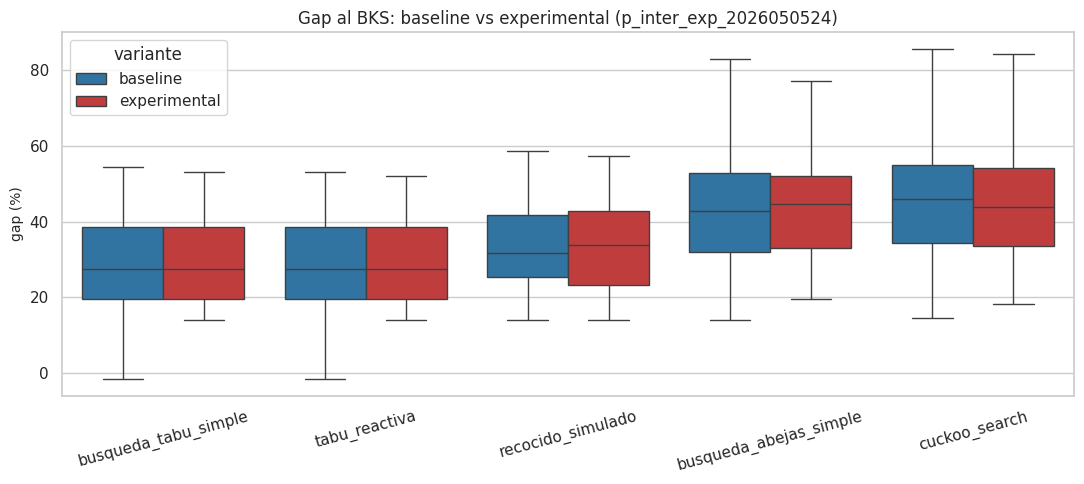

In [24]:
# Boxplot lado a lado por MH. Eje x ordenado por mediana del baseline para
# que las MH mas competitivas (TS Simple, RTS) queden a la izquierda.

df_mix = pd.concat([
    df_base[['metaheuristica', 'gap_bks_porcentaje']].assign(variante='baseline'),
    df_exp [['metaheuristica', 'gap_bks_porcentaje']].assign(variante='experimental'),
])
orden = (df_base.groupby('metaheuristica')['gap_bks_porcentaje']
                 .median().sort_values().index)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_mix, x='metaheuristica', y='gap_bks_porcentaje',
            hue='variante', order=orden, ax=ax, showfliers=False,
            palette={'baseline': '#1f77b4', 'experimental': '#d62728'})
ax.set_title('Gap al BKS: baseline vs experimental (p_inter_exp_2026050524)')
ax.set_xlabel(''); ax.set_ylabel('gap (%)')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

### 8.4 Tasa de factibilidad del mejor global

In [25]:
# Tasa de factibilidad del MEJOR global encontrado en cada corrida.
# En SA y ABC el baseline ya estaba en 1.0 (siempre factible); el cambio
# relevante es en TS Simple, RTS y Cuckoo.

tabla_fact = pd.concat([
    df_base.groupby('metaheuristica')['mejor_solucion_factible_final']
           .mean().rename('baseline'),
    df_exp.groupby('metaheuristica')['mejor_solucion_factible_final']
           .mean().rename('experimental'),
], axis=1).round(4)
tabla_fact['Δ_pp'] = ((tabla_fact['experimental'] - tabla_fact['baseline']) * 100).round(2)
tabla_fact

,baseline,experimental,Δ_pp
metaheuristica,,,
busqueda_abejas_simple,1.0000,1.0000,0.0000
busqueda_tabu_simple,0.0036,0.0174,1.3800
cuckoo_search,0.8872,0.9130,2.5800
recocido_simulado,1.0000,1.0000,0.0000
tabu_reactiva,0.0144,0.0261,1.1700


### 8.5 Cambio en la contribucion de operadores

La restriccion posicional + p_inter agresivo, ¿redistribuye el aporte de los
9 operadores entre intra e inter? Comparamos la tasa de mejora por
metaheuristica x operador antes y despues.

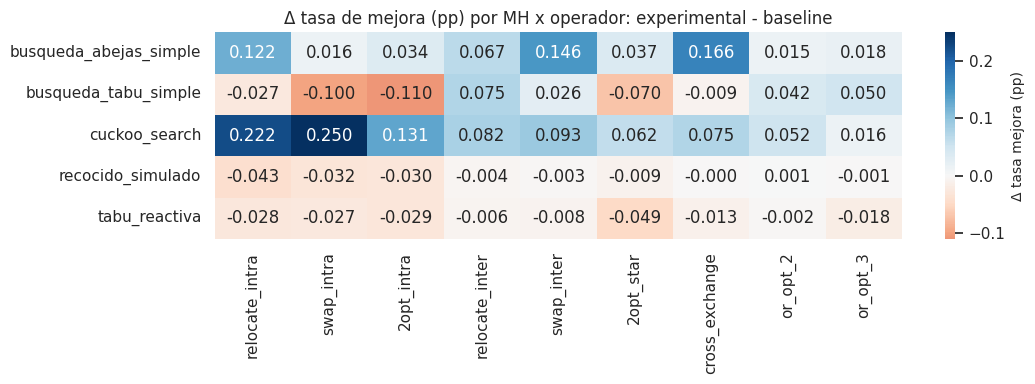

In [26]:
# Heatmap: cambio en la tasa de mejora (experimental - baseline) por MH x operador.
# Celdas azules = el operador mejoro su contribucion en la variante; rojas = empeoro.

def _tasa_mejora_pct(df_in):
    num = df_in.groupby('metaheuristica')[COLS_MEJORARON].sum()
    den = df_in.groupby('metaheuristica')[COLS_PROPUESTO].sum()
    num.columns = OPS; den.columns = OPS
    return (num / den.replace(0, np.nan)).fillna(0) * 100

tm_base = _tasa_mejora_pct(df_base)
tm_exp  = _tasa_mejora_pct(df_exp)
# Reordenamos las filas para que ambas matrices tengan el mismo orden de MH
mhs_comunes = sorted(set(tm_base.index) & set(tm_exp.index))
delta = tm_exp.loc[mhs_comunes] - tm_base.loc[mhs_comunes]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(delta, annot=True, fmt='.3f', center=0, cmap='RdBu',
            cbar_kws={'label': 'Δ tasa mejora (pp)'}, ax=ax)
ax.set_title('Δ tasa de mejora (pp) por MH x operador: experimental - baseline')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 8.6 Veredicto

La variante experimental **NO mejora el gap al BKS** en 4 de 5 metaheuristicas:

- **TS Simple y RTS Reactiva empeoran ~1.5 pp** (de ~28.5% a ~30.0% gap medio).
- **SA queda practicamente igual** (~0.3 pp peor).
- **ABC empeora ~1.2 pp**.
- **Solo Cuckoo Search mejora ~1.6 pp** (45.86% → 44.24%).

La **tasa de factibilidad** del mejor global mejora ligeramente en TS y RTS
(~1-2 puntos porcentuales mas factibles) pero sigue siendo desastrosa
(<3%), confirmando que el problema real es la calibracion de
`lambda_capacidad`, NO el sesgo inter/intra.

**Conclusion**: anclar la 1a tarea servida + forzar p_inter agresivo
restringe demasiado el espacio de busqueda en algoritmos basados en
busqueda local (SA, TS, RTS, ABC). Solo Cuckoo Search, cuyo operador
principal es el vuelo de Levy discreto (perturbacion larga, ya disruptiva
de por si), no se ve perjudicado por la restriccion adicional.

**Recomendacion**: descartar esta variante para SA, TS, RTS y ABC.
Considerar mantenerla solo para Cuckoo Search, donde mejora sin penalizar
la factibilidad. Para los problemas de factibilidad de TS/RTS, atacar
directamente `lambda_capacidad` (escalarlo mas agresivamente con
`n_tareas`) en lugar de modificar el sesgo de operadores.

## 9. Variante experimental strict_intra_inter_20260524

Esta seccion compara los resultados del experimento `strict_intra_inter_20260524` con el
baseline (secciones 1-7) y con la variante anterior `p_inter_exp_2026050524` (seccion 8).

Cambios de la nueva variante respecto al baseline:

1. **Conjunto reducido de operadores**: solo 5 (2 intra + 3 inter), eliminando `2opt_intra`,
   `relocate_inter`, `or_opt_2` y `or_opt_3`.
2. **Selector binario determinista**: viola -> inter, no viola -> intra (sin p_inter).
3. **Kick reactivo**: tras `max_iter_sin_mejora_kick=30` iteraciones sin mejorar el mejor
   global, se aplican operadores inter disruptivos aceptados incondicionalmente y se
   reinicia el contador. Limite: `max_resets=10` kicks por corrida.

Grid: 23 instancias x 3 repeticiones = **69 corridas por MH, 345 en total**.

### 9.1 Carga de los resultados del experimento

In [27]:
# Cargamos todos los CSVs parciales del experimento strict_intra_inter_20260524.
# Hay un duplicado por MH (gdb19 rep=1 aparece dos veces: smoke test + corrida real),
# por lo que aplicamos drop_duplicates conservando la ultima ocurrencia.
import glob as _glob

_dfs_strict: list[pd.DataFrame] = []
for _mh in ['sa', 'tabu_simple', 'tabu_reactiva', 'abc_simple', 'cuckoo']:
    _parts = _glob.glob(
        f'../experimentos/strict_intra_inter_20260524_{_mh}/_partials/*.csv'
    )
    for _f in _parts:
        _dfs_strict.append(pd.read_csv(_f, low_memory=False))

df_strict = (
    pd.concat(_dfs_strict, ignore_index=True)
      .drop_duplicates(subset=['metaheuristica', 'instancia', 'repeticion'], keep='last')
      .reset_index(drop=True)
)
df_strict['variante'] = 'strict_intra_inter'

print(f'Corridas cargadas  : {len(df_strict)}')
print(f'MH                 : {sorted(df_strict.metaheuristica.unique())}')
print(f'Instancias         : {df_strict.instancia.nunique()}')
print(f'Gap medio          : {df_strict.gap_bks_porcentaje.mean():.2f}%')
print(f'Factibilidad media : {df_strict.mejor_solucion_factible_final.mean()*100:.1f}%')
print(f'n_resets_kick medio: {df_strict.n_resets_kick.mean():.2f}')

# Operadores activos / eliminados en esta variante
OPS_STRICT_INTRA = ['relocate_intra', 'swap_intra']
OPS_STRICT_INTER = ['swap_inter', '2opt_star', 'cross_exchange']
OPS_STRICT_5     = OPS_STRICT_INTRA + OPS_STRICT_INTER

Corridas cargadas  : 345
MH                 : ['busqueda_abejas_simple', 'busqueda_tabu_simple', 'cuckoo_search', 'recocido_simulado', 'tabu_reactiva']
Instancias         : 23
Gap medio          : 36.86%
Factibilidad media : 61.4%
n_resets_kick medio: 8.67


### 9.2 Comparacion del gap al BKS por metaheuristica

In [28]:
# Tabla comparativa: baseline vs p_inter_exp vs strict_intra_inter.
# Para cada MH reportamos gap medio y mediano, y los deltas frente a baseline
# y frente a la variante experimental anterior (negativo = mejora).

def _resumen_gap(df_in: pd.DataFrame, label: str) -> pd.DataFrame:
    return (df_in.groupby('metaheuristica')['gap_bks_porcentaje']
                  .agg(mean='mean', median='median')
                  .rename(columns={'mean': f'mean_{label}',
                                   'median': f'median_{label}'}))

r_base   = _resumen_gap(df_base,   'base')
r_pinter = _resumen_gap(df_exp,    'pinter')
r_strict = _resumen_gap(df_strict, 'strict')

cmp_gap = r_base.join(r_pinter).join(r_strict)
cmp_gap['delta_strict_vs_base_mean']   = (cmp_gap['mean_strict'] - cmp_gap['mean_base']).round(2)
cmp_gap['delta_strict_vs_pinter_mean'] = (cmp_gap['mean_strict'] - cmp_gap['mean_pinter']).round(2)
cmp_gap = cmp_gap.round(2)

print('Gap (%) - baseline vs p_inter_exp vs strict_intra_inter')
print(cmp_gap.to_string())
print()
print('Negativo en delta_strict_vs_base = mejora respecto al baseline')
cmp_gap

Gap (%) - baseline vs p_inter_exp vs strict_intra_inter
                        mean_base  median_base  mean_pinter  median_pinter  mean_strict  median_strict  delta_strict_vs_base_mean  delta_strict_vs_pinter_mean
metaheuristica                                                                                                                                                
busqueda_abejas_simple    43.4100      42.7900      44.5800        44.6300      41.8900        41.7700                    -1.5300                      -2.7000
busqueda_tabu_simple      28.6700      27.5900      30.2600        27.5900      30.3600        29.2300                     1.6900                       0.1000
cuckoo_search             45.8600      46.0200      44.2400        43.9500      40.5000        40.5000                    -5.3600                      -3.7400
recocido_simulado         32.6900      31.8600      32.9600        33.8000      41.4600        38.6100                     8.7700                    

,mean_base,median_base,mean_pinter,median_pinter,mean_strict,median_strict,delta_strict_vs_base_mean,delta_strict_vs_pinter_mean
metaheuristica,,,,,,,,
busqueda_abejas_simple,43.4100,42.7900,44.5800,44.6300,41.8900,41.7700,-1.5300,-2.7000
busqueda_tabu_simple,28.6700,27.5900,30.2600,27.5900,30.3600,29.2300,1.6900,0.1000
cuckoo_search,45.8600,46.0200,44.2400,43.9500,40.5000,40.5000,-5.3600,-3.7400
recocido_simulado,32.6900,31.8600,32.9600,33.8000,41.4600,38.6100,8.7700,8.5000
tabu_reactiva,28.5100,27.5900,30.0400,27.5900,30.0700,27.5900,1.5600,0.0300


### 9.3 Distribucion del gap (boxplot lado a lado)

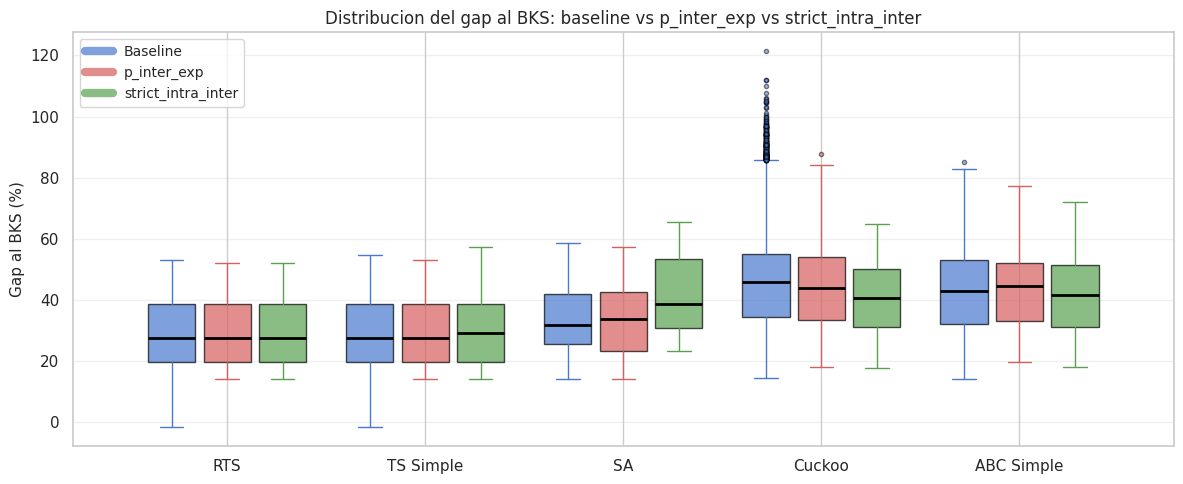

In [29]:
# Boxplot con 3 cajas por MH: baseline / p_inter_exp / strict_intra_inter.
# Ordenamos las MH por la mediana del gap del experimento strict para
# que las mas competitivas en esta variante queden a la izquierda.

MH_LABELS = {
    'recocido_simulado':      'SA',
    'busqueda_tabu_simple':   'TS Simple',
    'tabu_reactiva':          'RTS',
    'busqueda_abejas_simple': 'ABC Simple',
    'cuckoo_search':          'Cuckoo',
}

orden_mh = (df_strict.groupby('metaheuristica')['gap_bks_porcentaje']
                       .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(orden_mh))
w = 0.28

fuentes = [
    (df_base,   'Baseline',           '#4878CF'),
    (df_exp,    'p_inter_exp',        '#D65F5F'),
    (df_strict, 'strict_intra_inter', '#59A14F'),
]
for i, (src_df, label, color) in enumerate(fuentes):
    data_plot = [
        src_df[src_df.metaheuristica == mh]['gap_bks_porcentaje'].dropna()
        for mh in orden_mh
    ]
    ax.boxplot(
        data_plot,
        positions=x + (i - 1) * w,
        widths=w * 0.85,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.7),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.5),
    )
    ax.plot([], [], color=color, linewidth=6, alpha=0.7, label=label)

ax.set_xticks(x)
ax.set_xticklabels([MH_LABELS.get(m, m) for m in orden_mh], fontsize=11)
ax.set_ylabel('Gap al BKS (%)', fontsize=11)
ax.set_title('Distribucion del gap al BKS: baseline vs p_inter_exp vs strict_intra_inter')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 Tasa de factibilidad del mejor global

In [30]:
# Tasa de factibilidad: fraccion de corridas cuyo mejor global final es factible.
# Reportamos los 3 escenarios y el delta strict-base en puntos porcentuales.

fact_base   = df_base.groupby('metaheuristica')['mejor_solucion_factible_final'].mean() * 100
fact_pinter = df_exp.groupby('metaheuristica')['mejor_solucion_factible_final'].mean() * 100
fact_strict = df_strict.groupby('metaheuristica')['mejor_solucion_factible_final'].mean() * 100

cmp_fact = pd.DataFrame({
    'Baseline (%)':           fact_base,
    'p_inter_exp (%)':        fact_pinter,
    'strict_intra_inter (%)': fact_strict,
}).round(1)
cmp_fact['delta_strict_base_pp'] = (fact_strict - fact_base).round(1)
print(cmp_fact.to_string())
cmp_fact

                        Baseline (%)  p_inter_exp (%)  strict_intra_inter (%)  delta_strict_base_pp
metaheuristica                                                                                     
busqueda_abejas_simple      100.0000         100.0000                100.0000                0.0000
busqueda_tabu_simple          0.4000           1.7000                 10.1000                9.8000
cuckoo_search                88.7000          91.3000                 97.1000                8.4000
recocido_simulado           100.0000         100.0000                100.0000                0.0000
tabu_reactiva                 1.4000           2.6000                  0.0000               -1.4000


,Baseline (%),p_inter_exp (%),strict_intra_inter (%),delta_strict_base_pp
metaheuristica,,,,
busqueda_abejas_simple,100.0000,100.0000,100.0000,0.0000
busqueda_tabu_simple,0.4000,1.7000,10.1000,9.8000
cuckoo_search,88.7000,91.3000,97.1000,8.4000
recocido_simulado,100.0000,100.0000,100.0000,0.0000
tabu_reactiva,1.4000,2.6000,0.0000,-1.4000


### 9.5 Distribucion del numero de kicks (n_resets_kick)

El kick reactivo se dispara cuando `iter_sin_mejora >= max_iter_sin_mejora_kick`.
El parametro `max_resets=10` limita el total de kicks por corrida. Si la mayoria de
las corridas llegan al tope, el mecanismo no esta logrando escapar de los optimos
locales y solo agrega ruido.

Estadisticas de n_resets_kick por MH
              mean  median  max  pct_tope
ABC Simple  9.2200 10.0000   10   69.5700
TS Simple   9.8800 10.0000   10   89.8600
Cuckoo      9.8700 10.0000   10   95.6500
SA         10.0000 10.0000   10  100.0000
RTS         4.3800  3.0000   10   18.8400

pct_tope: porcentaje de corridas que alcanzaron max_resets=10


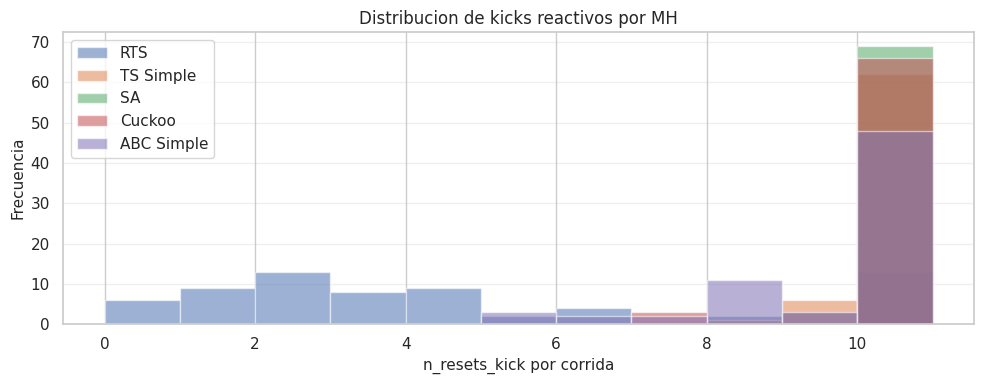

In [31]:
# Estadisticas y distribucion de n_resets_kick por MH.
kicks_stats = (df_strict.groupby('metaheuristica')['n_resets_kick']
               .agg(mean='mean', median='median', max='max',
                    pct_tope=lambda x: (x >= 10).mean() * 100)
               .round(2))
kicks_stats.index = [MH_LABELS.get(m, m) for m in kicks_stats.index]
print('Estadisticas de n_resets_kick por MH')
print(kicks_stats.to_string())
print()
print('pct_tope: porcentaje de corridas que alcanzaron max_resets=10')

fig, ax = plt.subplots(figsize=(10, 4))
for mh in orden_mh:
    datos = df_strict[df_strict.metaheuristica == mh]['n_resets_kick']
    ax.hist(datos, bins=range(0, 12), alpha=0.55,
            label=MH_LABELS.get(mh, mh), density=False)
ax.set_xlabel('n_resets_kick por corrida', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribucion de kicks reactivos por MH')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 Cambio en la contribucion de operadores (strict vs baseline)

Solo los 5 operadores activos en `strict_intra_inter_20260524` son relevantes.
Los 4 eliminados (`2opt_intra`, `relocate_inter`, `or_opt_2`, `or_opt_3`) deben
tener tasa de mejora ~= 0 en el experimento.

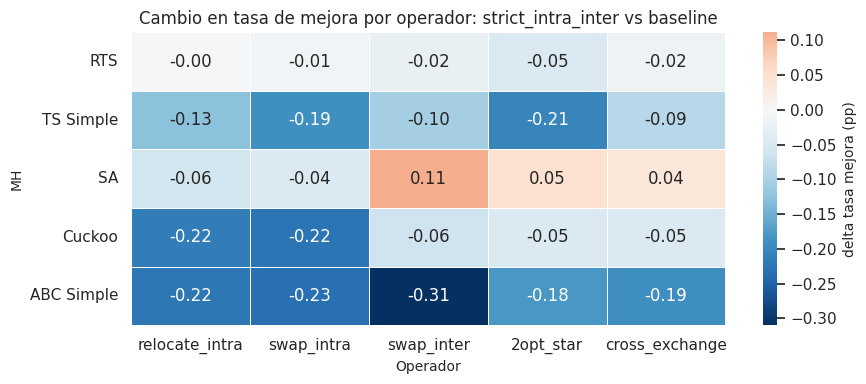

In [32]:
# Heatmap: delta de tasa de mejora (strict - baseline) por MH x operador,
# restringido a los 5 operadores activos en la variante strict_intra_inter.
# Celdas azules = el operador mejoro su contribucion; rojas = empeoro.

def _tasa_mejora_por_mh(df_in: pd.DataFrame, ops: list[str]) -> pd.DataFrame:
    filas: dict[str, pd.Series] = {}
    for mh, grp in df_in.groupby('metaheuristica'):
        prop = grp[[f'propuesto_{op}' for op in ops]].sum()
        mejo = grp[[f'mejoraron_{op}' for op in ops]].sum()
        prop.index = ops
        mejo.index = ops
        tasa = (mejo / prop.replace(0, np.nan)).fillna(0.0)
        filas[MH_LABELS.get(mh, mh)] = tasa
    return pd.DataFrame(filas).T

tm_base_5   = _tasa_mejora_por_mh(df_base,   OPS_STRICT_5)
tm_strict_5 = _tasa_mejora_por_mh(df_strict, OPS_STRICT_5)

filas_orden = [MH_LABELS[m] for m in orden_mh if m in MH_LABELS]
delta_tm = (tm_strict_5 - tm_base_5).reindex(filas_orden)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    delta_tm * 100,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'delta tasa mejora (pp)'},
)
ax.set_title('Cambio en tasa de mejora por operador: strict_intra_inter vs baseline')
ax.set_xlabel('Operador')
ax.set_ylabel('MH')
plt.tight_layout()
plt.show()

### 9.7 Veredicto

La variante **strict_intra_inter_20260524** produce resultados claramente mixtos sobre las **345 corridas** (5 MH x 23 instancias x 3 repeticiones): **2 de las 5 metaheuristicas mejoran** frente al baseline (**Cuckoo y ABC**), las otras tres empeoran (**TS Simple, RTS y, sobre todo, SA**), y el gap medio global queda en **36.86%** con factibilidad media de **61.4%** y un promedio de **8.67 kicks** por corrida.

**Cuckoo Search es la principal beneficiada**: su gap medio cae de **45.86% a 40.50% (-5.36 pp)** respecto al baseline y **-3.74 pp** respecto a `p_inter_exp_2026050524`, mientras que la tasa de factibilidad sube de **88.7% a 97.1% (+8.4 pp)**. El selector binario determinista combinado con el kick reactivo encaja especialmente bien con la estructura poblacional de Cuckoo: la perturbacion inter-ruta sobre todos los nidos actua como una reinicializacion diversificada que el vuelo de Levy por si solo no estaba consiguiendo, y la regla `viola -> inter / no viola -> intra` mantiene la presion hacia la factibilidad sin sacrificar la intensificacion local.

**ABC Simple tambien mejora**, aunque de forma mas modesta: **-1.53 pp** en gap medio (43.41% a 41.89%) y **-2.70 pp** frente a `p_inter_exp`, manteniendo el 100% de factibilidad que ya tenia desde el baseline. Al igual que Cuckoo, se beneficia de que la perturbacion poblacional del kick actua sobre toda la colonia y no sobre una unica solucion, sumandose a los mecanismos de exploracion ya presentes (scouts y limite de abandono).

**TS Simple y RTS empeoran marginalmente** (**+1.69 pp** y **+1.56 pp** en gap medio respectivamente), con un comportamiento muy distinto entre ambas. En **TS Simple el kick satura** alcanzando el tope `max_resets=10` en el **89.86%** de las corridas, indicio claro de que `max_iter_sin_mejora_kick=30` es demasiado bajo para esta MH: el algoritmo se reinicia antes de poder explotar su lista tabu. Pese a eso, la factibilidad sube de **0.4% a 10.1% (+9.8 pp)**, demostrando que el selector binario si esta empujando hacia capacidad factible, solo que a costa del costo objetivo. **RTS muestra el patron opuesto**: es la unica MH donde los kicks **no saturan** (media de **4.38**, solo **18.84%** de corridas al tope), porque su mecanismo reactivo nativo de tenure ya diversifica suficientemente; pero su factibilidad cae de **1.4% a 0.0%**, lo que sugiere que combinar el selector binario con el escape nativo de RTS genera una presion excesiva hacia operadores inter-ruta que deja al algoritmo atascado en soluciones infactibles.

**SA es la gran perdedora** con **+8.77 pp** de gap medio (32.69% a 41.46%) y **+8.50 pp** frente a `p_inter_exp`. El kick **satura en el 100%** de las corridas, lo que significa que SA esta siendo interrumpido continuamente por el reset antes de que su enfriamiento natural pueda explotar el regimen de baja temperatura donde concentra su intensificacion. Para SA la combinacion `max_iter_sin_mejora_kick=30` + `max_resets=10` es practicamente equivalente a forzar 10 reinicios obligatorios, anulando el esquema de templado.

**Diagnostico del kick reactivo**: la saturacion de `n_resets` en **SA (100%), Cuckoo (95.65%) y TS Simple (89.86%)** indica que el criterio `max_resets=10` domina la terminacion de estas corridas (la MH para por kicks antes de agotar sus iteraciones naturales). ABC queda en una zona intermedia (**69.57%** al tope), y RTS es el unico caso donde el kick funciona como mecanismo de escape ocasional. La saturacion resulta neutra o beneficiosa para las MHs poblacionales (Cuckoo y ABC), donde la perturbacion redistribuye toda la poblacion, y claramente daniña para las MHs de solucion unica con cronograma propio (SA y, en menor medida, TS Simple), donde el reset interrumpe procesos de convergencia que necesitan tiempo continuo.

**Comparacion con `p_inter_exp_2026050524`**: el selector binario estricto supera claramente a la politica `p_inter` agresiva en **Cuckoo (-3.74 pp)** y **ABC (-2.70 pp)**, queda casi empatado en **TS Simple (+0.10 pp)** y **RTS (+0.03 pp)**, y es marcadamente peor en **SA (+8.50 pp)** por las razones de saturacion ya descritas. Esto confirma que la regla determinista `viola -> inter` es mas efectiva que la aleatoria para MHs poblacionales, pero que ninguno de los dos enfoques mejora el baseline de forma consistente para las MHs de solucion unica (SA, TS Simple, RTS), lo que vuelve a apuntar a que el problema raiz de TS y RTS sigue siendo la calibracion de `lambda_capacidad` mas que el sesgo entre operadores.

**Conclusion**: la combinacion de **selector binario determinista + kick reactivo + conjunto reducido a 5 operadores** es prometedora para las metaheuristicas poblacionales (Cuckoo y ABC), donde Cuckoo produce la mayor mejora absoluta observada en todos los experimentos del notebook. Para **TS Simple** el siguiente paso natural es subir `max_iter_sin_mejora_kick` a un valor mas alto (>=80 iteraciones) para evitar la saturacion prematura. Para **SA** conviene desactivar el kick por completo o usarlo solo en la fase de alta temperatura, para no interferir con el cronograma de enfriamiento. Para **RTS** la propia naturaleza de su mecanismo reactivo hace innecesario el kick adicional. Y la baja factibilidad persistente de TS Simple y RTS sigue requiriendo atacar directamente la calibracion de `lambda_capacidad` con `n_tareas`, como ya se concluia en la seccion 8.